In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import ipywidgets as widgets

In [4]:
import pandas as pd

file_path = "data/email-spam-classification.csv"
df = pd.read_csv(file_path)

print(df.head())


  label                                               text
0   ham                   Hey, are we still meeting today?
1  spam  Congratulations! You won a free lottery ticket...
2   ham                         Let's have lunch tomorrow.
3  spam  URGENT! Your account has been suspended. Click...


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   4 non-null      object
 1   text    4 non-null      object
dtypes: object(2)
memory usage: 196.0+ bytes


In [6]:
import pandas as pd

# Step 1: Load the CSV file
df = pd.read_csv("data/email-spam-classification.csv")

# Step 2: Rename columns for clarity
df.rename(columns={'label': 'Label', 'text': 'Message'}, inplace=True)

# Step 3: Remove any empty rows (if present)
df.dropna(inplace=True)

# Step 4: Convert 'Label' to category type
df['Label'] = df['Label'].astype('category')

# Step 5: Clean text messages by making them lowercase
df['Message'] = df['Message'].str.lower()

# Step 6: Show the cleaned DataFrame
print(df.head())
print(df.info())


  Label                                            Message
0   ham                   hey, are we still meeting today?
1  spam  congratulations! you won a free lottery ticket...
2   ham                         let's have lunch tomorrow.
3  spam  urgent! your account has been suspended. click...
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   Label    4 non-null      category
 1   Message  4 non-null      object  
dtypes: category(1), object(1)
memory usage: 292.0+ bytes
None


In [28]:
# Filter dataset to relevant features
df_reduced = df[['Label', 'Message']]

# Print the first few rows to verify
print(df_reduced.head())




  Label                                            Message
0   ham                   hey, are we still meeting today?
1  spam  congratulations! you won a free lottery ticket...
2   ham                         let's have lunch tomorrow.
3  spam  urgent! your account has been suspended. click...


In [29]:
# Assuming df_reduced has columns 'Label' and 'Message'

# 1. Count how many messages are spam and ham
print("Message counts by Label:")
print(df_reduced['Label'].value_counts())

# 2. Create a new column for message length
df_reduced['Message_Length'] = df_reduced['Message'].apply(len)

# 3. Average message length by Label
print("\nAverage message length by Label:")
print(df_reduced.groupby('Label', observed=True)['Message_Length'].mean())

# 4. Detailed stats of message length by Label
print("\nMessage length statistics by Label:")
print(df_reduced.groupby('Label', observed=True)['Message_Length'].describe())

# 5. Optional: Check correlation between Label (encoded) and Message_Length
df_reduced['Label_Num'] = df_reduced['Label'].map({'ham': 0, 'spam': 1})
print("\nCorrelation between label and message length:")
print(df_reduced[['Label_Num', 'Message_Length']].corr())


Message counts by Label:
Label
ham     2
spam    2
Name: count, dtype: int64

Average message length by Label:
Label
ham     29.0
spam    59.5
Name: Message_Length, dtype: float64

Message length statistics by Label:
       count  mean       std   min    25%   50%    75%   max
Label                                                       
ham      2.0  29.0  4.242641  26.0  27.50  29.0  30.50  32.0
spam     2.0  59.5  3.535534  57.0  58.25  59.5  60.75  62.0

Correlation between label and message length:
                Label_Num  Message_Length
Label_Num        1.000000        0.983999
Message_Length   0.983999        1.000000


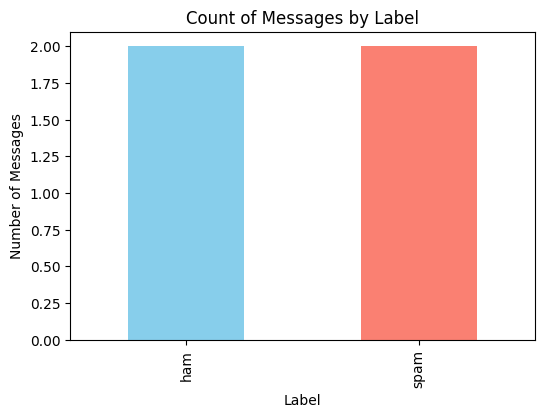

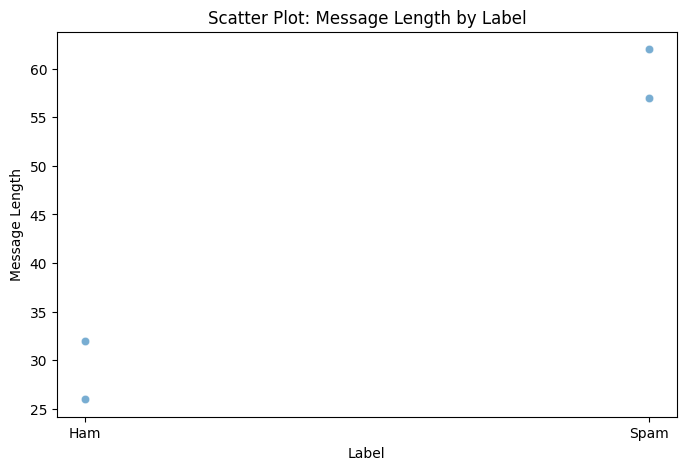

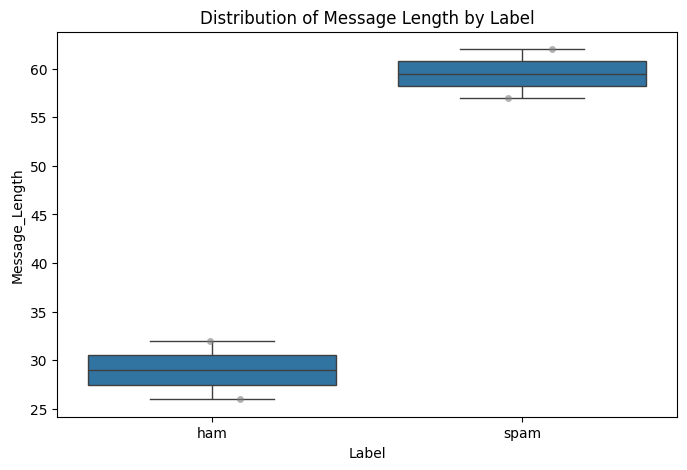

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming df is your original DataFrame
# Create reduced dataset
df_reduced = df[['Label', 'Message']].copy()

# Fix possible label typos if any (like 'pam' instead of 'spam')
df_reduced['Label'] = df_reduced['Label'].replace({'pam': 'spam'})

# Create message length column
df_reduced['Message_Length'] = df_reduced['Message'].apply(len)

# Map Label to numeric for scatter plot
df_reduced['Label_Num'] = df_reduced['Label'].map({'ham': 0, 'spam': 1})

# 1. Bar Chart: Count of messages by Label
plt.figure(figsize=(6,4))
df_reduced['Label'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Count of Messages by Label')
plt.xlabel('Label')
plt.ylabel('Number of Messages')
plt.show()

# 2. Scatter Plot: Message length vs. Label (numerical)
plt.figure(figsize=(8,5))
sns.scatterplot(x='Label_Num', y='Message_Length', data=df_reduced, alpha=0.6)
plt.xticks([0,1], ['Ham', 'Spam'])
plt.title('Scatter Plot: Message Length by Label')
plt.xlabel('Label')
plt.ylabel('Message Length')
plt.show()

# 3. Boxplot + Stripplot (without palette to avoid warning)
plt.figure(figsize=(8,5))
sns.boxplot(x='Label', y='Message_Length', data=df_reduced)  # Removed palette to avoid warning
sns.stripplot(x='Label', y='Message_Length', data=df_reduced, color='gray', jitter=True, alpha=0.6)
plt.title('Distribution of Message Length by Label')
plt.show()
